# Ciclo Técnico-Executivo - Antecipação de Alertas Críticos

Este notebook consolida a história completa do projeto: **extração de dados -> contrato/qualidade -> rotulação -> EDA -> features -> treinamento/seleção -> resultado operacional -> recomendação**.

A leitura é técnico-executiva. Cada seção conecta a evidência produzida pela pipeline ao impacto esperado na operação de manutenção.

| Seção | Pergunta respondida |
|---|---|
| 1. Linha do tempo da solução | Como os dados viram uma decisão operacional? |
| 2. Extração e contrato | A base é íntegra e suficiente para modelagem? |
| 3. Rotulação | O que significa antecipar um alerta crítico em 4 horas? |
| 4. EDA orientada à decisão | Há sinal temporal e operacional para priorizar risco? |
| 5. Feature engineering | Quais sinais o modelo usa sem vazamento de futuro? |
| 6. Treinamento e seleção | Qual candidato maximiza desempenho operacional? |
| 7. Threshold técnico | Como o score se comporta ciclo-a-ciclo? |
| 8. Resultado operacional | Top15 Tag-dia entrega ganho real sobre aleatório? |
| 9. Segmentos e riscos | Onde o modelo é forte, frágil ou inconclusivo? |
| 10. Decisão executiva | O projeto está pronto para piloto assistido? |

**Fonte de verdade:** artefatos versionados em `data/processed/`, `reports/`, `docs/` e `models/model_selected.joblib`.


In [26]:
from pathlib import Path
import sys
import json
import math
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Markdown

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if not (ROOT / "reports").exists() and (ROOT.parent / "reports").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.utils.plot_theme import apply_manager_theme, add_source_note, PALETTE

try:
    from src.evaluation.operational_scorecard import decode_one_hot_prefix
except ModuleNotFoundError:
    def decode_one_hot_prefix(df, prefix):
        columns = [column for column in df.columns if column.startswith(f"{prefix}_")]
        if not columns:
            return pd.Series(["desconhecido"] * len(df), index=df.index)
        matrix = df[columns].fillna(False).astype(bool)
        decoded = matrix.idxmax(axis=1).str.replace(f"{prefix}_", "", regex=False)
        decoded.loc[~matrix.any(axis=1)] = "desconhecido"
        return decoded

apply_manager_theme()
plt.rcParams.update({"axes.titlesize": 14, "axes.labelsize": 11, "figure.dpi": 120})

REPORTS = ROOT / "reports"
DATA = ROOT / "data" / "processed"
RAW = ROOT / "data" / "raw" / "datasets" / "datasets"
DOCS = ROOT / "docs"
MODELS = ROOT / "models"


def read_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def first_existing(*paths):
    for candidate in paths:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Nenhum artefato encontrado entre: {[str(p) for p in paths]}")


def pct(value, digits=1):
    return f"{value:.{digits}%}"


def fmt_int(value):
    return f"{int(value):,}".replace(",", ".")


def short_path(path):
    path = Path(path)
    try:
        return str(path.relative_to(ROOT))
    except ValueError:
        return str(path)

# Dados processados e splits oficiais.
features_df = pd.read_parquet(DATA / "features" / "features_dataset.parquet")
split_train_df = pd.read_parquet(DATA / "features" / "splits" / "features_train.parquet")
split_val_df = pd.read_parquet(DATA / "features" / "splits" / "features_val.parquet")
split_test_df = pd.read_parquet(DATA / "features" / "splits" / "features_test.parquet")

for df in [features_df, split_train_df, split_val_df, split_test_df]:
    for col in ["Inicio", "Fim"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce", utc=True)

# Relatórios oficiais.
quality_json = read_json(DATA / "labeled" / "quality_report_ingestao.json")
labeling_json = read_json(DATA / "labeled" / "labeling_report.json")
feature_json = read_json(DATA / "features" / "feature_report.json")
split_json = read_json(DATA / "features" / "splits" / "split_metadata.json")
oper_json = read_json(REPORTS / "operational_metrics_report.json")
segment_json = read_json(REPORTS / "segment_operational_report.json")
selection_report_path = first_existing(REPORTS / "model_selection_report.json", REPORTS / "model_benchmark_report.json")
selection_json = read_json(selection_report_path)

selection_df = pd.read_csv(first_existing(REPORTS / "model_selection_report.csv", REPORTS / "model_benchmark_report.csv"))
oper_budget_df = pd.read_csv(REPORTS / "operational_budget_metrics.csv")
oper_topk_df = pd.read_csv(REPORTS / "operational_daily_topk_metrics.csv")
segment_threshold_df = pd.read_csv(REPORTS / "segment_threshold_metrics.csv")
segment_topk_df = pd.read_csv(REPORTS / "segment_topk_tag_day_metrics.csv")
segment_hotspots_df = pd.read_csv(REPORTS / "segment_tag_hotspots.csv")
threshold_curve_df = pd.read_csv(first_existing(REPORTS / "model_selected_threshold_curve.csv", REPORTS / "hist_gbdt_threshold_curve.csv"))
feature_importance_df = pd.read_csv(first_existing(REPORTS / "model_selected_feature_importance.csv", REPORTS / "model_feature_importance.csv"))
backtest_df = pd.read_csv(first_existing(REPORTS / "model_selection_backtest_report.csv", REPORTS / "hist_gbdt_backtest_report.csv"))

selected_model = selection_json.get("selected_model") or selection_json.get("winner")
model_name = selected_model["model_name"]
threshold_test = next(item for item in oper_json["threshold_metrics"] if item["split"] == "test")
threshold = float(threshold_test["threshold"])
topk15 = oper_topk_df.query("split == 'test' and top_k_tags_per_day == 15").iloc[0]

# Enriquecimentos para gráficos.
features_df["dia"] = features_df["Fim"].dt.floor("D")
features_df["frota_decoded"] = decode_one_hot_prefix(features_df, "Frota")
features_df["tipo_decoded"] = decode_one_hot_prefix(features_df, "Tipo")
if "turno" in features_df.columns:
    features_df["turno"] = features_df["turno"].astype(str)

assert "target_4h" in features_df.columns, "Coluna target_4h ausente"
assert model_name in selection_df["model_name"].values, "Modelo selecionado não encontrado no relatório de seleção"
assert abs(threshold - float(selected_model.get("test_threshold", selected_model.get("threshold", threshold)))) < 1e-9, "Threshold dessincronizado entre relatórios"

summary_status = pd.DataFrame({
    "Item": [
        "Registros de features", "Período coberto", "Modelo selecionado", "Threshold oficial",
        "Precision@Top15", "Recall@Top15", "Lift@Top15", "Artefato operacional",
    ],
    "Valor": [
        fmt_int(len(features_df)),
        f"{features_df['Fim'].min().date()} a {features_df['Fim'].max().date()}",
        model_name,
        f"{threshold:.6f}",
        f"{topk15['precision_at_k']:.4f}",
        f"{topk15['recall_at_k']:.4f}",
        f"{topk15['lift_vs_random']:.4f}x",
        oper_json.get("model_path", "models/model_selected.joblib"),
    ],
})

display(summary_status.style.set_caption("Resumo executivo sincronizado com os artefatos oficiais").hide(axis="index"))
display(Markdown(
    f"**Leitura executiva:** notebook carregado com `{fmt_int(len(features_df))}` ciclos, "
    f"modelo `{model_name}` e scorecard operacional Top15 vindo de `reports/`."
))

Item,Valor
Registros de features,377.907
Período coberto,2025-01-01 a 2025-07-01
Modelo selecionado,lightgbm_optuna
Threshold oficial,0.139074
Precision@Top15,0.6756
Recall@Top15,0.7361
Lift@Top15,2.0774x
Artefato operacional,models/model_selected.joblib


**Leitura executiva:** notebook carregado com `377.907` ciclos, modelo `lightgbm_optuna` e scorecard operacional Top15 vindo de `reports/`.

## 1. Linha do Tempo da Solução

A solução foi desenhada para transformar registros históricos em uma lista diária de prioridade por `Tag`. A linha abaixo mostra o encadeamento entre dados, modelagem e decisão operacional.


Etapa,Entrada,Evidência,Saída
Dados brutos,apontamentos + telemetria,data/raw/,registros operacionais e eventos
Ingestão e contrato,apontamentos,quality_report_ingestao.json,base validada
Rotulação,telemetria crítica,labeling_report.json,target_4h
Feature engineering,base rotulada,feature_report.json,57 colunas / 48 modeláveis
Split temporal,features,split_metadata.json,70/15/15
Seleção robusta,candidatos Optuna,model_selection_report.json,lightgbm_optuna
Operação assistida,scores,operational_metrics_report.json,Top15 Tag-dia


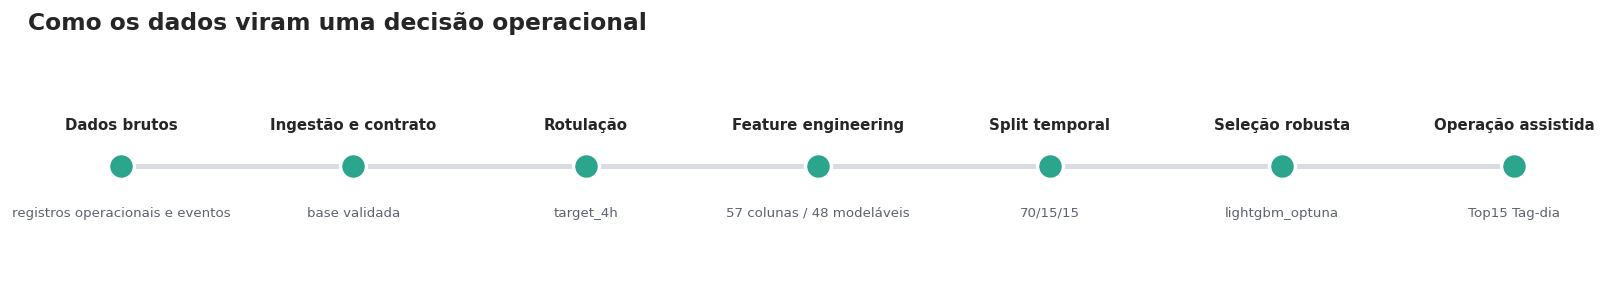

**Insight operacional:** a decisão final não depende de uma célula isolada do notebook; ela é rastreável por artefatos versionados da ingestão até a inferência.

In [39]:
pipeline_steps = pd.DataFrame([
    {"Etapa": "Dados brutos", "Entrada": "apontamentos + telemetria", "Evidência": "data/raw/", "Saída": "registros operacionais e eventos"},
    {"Etapa": "Ingestão e contrato", "Entrada": "apontamentos", "Evidência": "quality_report_ingestao.json", "Saída": "base validada"},
    {"Etapa": "Rotulação", "Entrada": "telemetria crítica", "Evidência": "labeling_report.json", "Saída": "target_4h"},
    {"Etapa": "Feature engineering", "Entrada": "base rotulada", "Evidência": "feature_report.json", "Saída": "57 colunas / 48 modeláveis"},
    {"Etapa": "Split temporal", "Entrada": "features", "Evidência": "split_metadata.json", "Saída": "70/15/15"},
    {"Etapa": "Seleção robusta", "Entrada": "candidatos Optuna", "Evidência": "model_selection_report.json", "Saída": model_name},
    {"Etapa": "Operação assistida", "Entrada": "scores", "Evidência": "operational_metrics_report.json", "Saída": "Top15 Tag-dia"},
])

display(pipeline_steps.style.hide(axis="index").set_caption("Fluxo consolidado do projeto"))

fig, ax = plt.subplots(figsize=(14, 2.8))
x = np.arange(len(pipeline_steps))
ax.plot(x, np.zeros_like(x), color=PALETTE["gray"], linewidth=3, zorder=1)
ax.scatter(x, np.zeros_like(x), s=240, color=PALETTE["teal"], edgecolor="white", linewidth=2, zorder=2)
for idx, row in pipeline_steps.iterrows():
    ax.text(idx, 0.10, row["Etapa"], ha="center", va="bottom", fontsize=9, fontweight="bold")
    ax.text(idx, -0.12, row["Saída"], ha="center", va="top", fontsize=8, color=PALETTE["slate"], wrap=True)
ax.set_ylim(-0.35, 0.35)
ax.set_xlim(-0.4, len(pipeline_steps) - 0.6)
ax.axis("off")
ax.set_title("Como os dados viram uma decisão operacional", loc="left")
plt.tight_layout()
plt.show()

display(Markdown("**Insight operacional:** a decisão final não depende de uma célula isolada do notebook; ela é rastreável por artefatos versionados da ingestão até a inferência."))

## 2. Extração, Ingestão e Contrato dos Dados

Antes da modelagem, o projeto valida se os dados têm volume, datas e campos mínimos para sustentar uma análise temporal. Esta seção resume os contratos oficiais de ingestão, rotulação, features e split.


Indicador,Valor,Fonte
Registros de apontamentos,377.907,quality_report_ingestao.json
Duplicatas completas,0,quality_report_ingestao.json
Duplicatas Tag-Inicio-Fim,101 (0.0267%),quality_report_ingestao.json
Datas inválidas,0,quality_report_ingestao.json
Arquivos de telemetria processados,6,labeling_report.json
Linhas de eventos de telemetria,37.164.054,labeling_report.json
Linhas de features,377.907,feature_report.json
Features modeláveis,48,model_selection_report.json


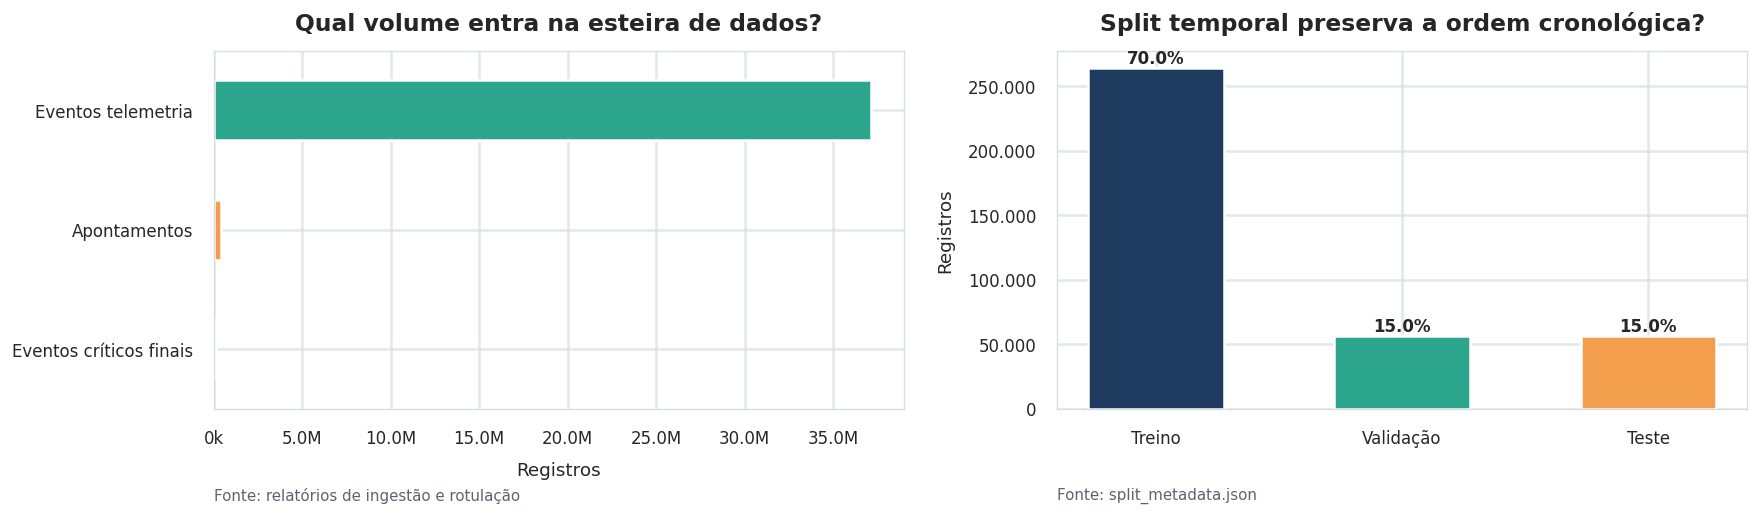

Split,Registros,Início,Fim,% do total
Treino,264.534,2025-01-01 03:03:43+00:00,2025-05-06 06:00:00+00:00,70.0%
Validação,56.686,2025-05-06 06:00:00+00:00,2025-06-02 15:00:00+00:00,15.0%
Teste,56.687,2025-06-02 15:00:00+00:00,2025-07-01 03:00:00+00:00,15.0%


**Insight operacional:** a base é íntegra para o fluxo atual: não há duplicatas completas, datas inválidas ou duração negativa, e o split temporal isola o teste para reporte final.

In [40]:
telemetry_files = sorted((RAW / "telemetria").glob("*.parquet"))
apontamentos_file = RAW / "apontamentos" / "desenvolver_apontamentos.parquet"

contract_cards = pd.DataFrame([
    {"Indicador": "Registros de apontamentos", "Valor": fmt_int(quality_json["total_records"]), "Fonte": "quality_report_ingestao.json"},
    {"Indicador": "Duplicatas completas", "Valor": fmt_int(quality_json["duplicate_full_rows"]), "Fonte": "quality_report_ingestao.json"},
    {"Indicador": "Duplicatas Tag-Inicio-Fim", "Valor": f"{fmt_int(quality_json['duplicate_tag_inicio_fim'])} ({quality_json['duplicate_tag_inicio_fim_pct']:.4f}%)", "Fonte": "quality_report_ingestao.json"},
    {"Indicador": "Datas inválidas", "Valor": fmt_int(quality_json["invalid_inicio"] + quality_json["invalid_fim"]), "Fonte": "quality_report_ingestao.json"},
    {"Indicador": "Arquivos de telemetria processados", "Valor": fmt_int(labeling_json["files_processed"]), "Fonte": "labeling_report.json"},
    {"Indicador": "Linhas de eventos de telemetria", "Valor": fmt_int(labeling_json["rows_total_events"]), "Fonte": "labeling_report.json"},
    {"Indicador": "Linhas de features", "Valor": fmt_int(feature_json["rows"]), "Fonte": "feature_report.json"},
    {"Indicador": "Features modeláveis", "Valor": fmt_int(selection_json["feature_count"]), "Fonte": "model_selection_report.json"},
])

display(contract_cards.style.hide(axis="index").set_caption("Contrato e cobertura dos dados"))

split_table = pd.DataFrame([
    {"Split": "Treino", "Registros": split_json["rows_train"], "Início": split_json["train_start"], "Fim": split_json["train_end"]},
    {"Split": "Validação", "Registros": split_json["rows_val"], "Início": split_json["val_start"], "Fim": split_json["val_end"]},
    {"Split": "Teste", "Registros": split_json["rows_test"], "Início": split_json["test_start"], "Fim": split_json["test_end"]},
])
split_table["% do total"] = split_table["Registros"] / split_json["rows_total"]

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

ax = axes[0]
raw_counts = pd.Series({
    "Apontamentos": quality_json["total_records"],
    "Eventos telemetria": labeling_json["rows_total_events"],
    "Eventos críticos finais": labeling_json["rows_critical_events_final"],
})
raw_counts.sort_values().plot(kind="barh", ax=ax, color=[PALETTE["blue"], PALETTE["orange"], PALETTE["teal"]])
ax.set_title("Qual volume entra na esteira de dados?")
ax.set_xlabel("Registros")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1_000_000:.1f}M" if x >= 1_000_000 else f"{x/1_000:.0f}k"))
add_source_note(ax, "Fonte: relatórios de ingestão e rotulação")

ax = axes[1]
colors = [PALETTE["navy"], PALETTE["teal"], PALETTE["orange"]]
bars = ax.bar(split_table["Split"], split_table["Registros"], color=colors, width=0.55)
for bar, share in zip(bars, split_table["% do total"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{share:.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Split temporal preserva a ordem cronológica?")
ax.set_ylabel("Registros")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
add_source_note(ax, "Fonte: split_metadata.json")

plt.tight_layout()
plt.show()

display(split_table.assign(Registros=split_table["Registros"].map(fmt_int), **{"% do total": split_table["% do total"].map(lambda v: f"{v:.1%}")}).style.hide(axis="index"))
display(Markdown("**Insight operacional:** a base é íntegra para o fluxo atual: não há duplicatas completas, datas inválidas ou duração negativa, e o split temporal isola o teste para reporte final."))

## 3. Rotulação: O Que Significa Antecipar um Alerta Crítico?

O alvo `target_4h` vale `1` quando um ciclo antecede um evento crítico em até 4 horas. Essa janela é curta o suficiente para acionar inspeção preventiva e longa o bastante para permitir antecipação operacional.

Colunas que enxergam o futuro são usadas apenas para criar o alvo e depois são removidas da modelagem.


Indicador,Valor
Eventos críticos finais,107.002
Tags com sobreposição,34
Ciclos positivos target_4h,70.811 (18.74%)
Janela de antecipação,4 horas
Cobertura de eventos críticos,2025-01-01 03:37:35.267000+00:00 a 2025-07-01 02:59:08.113000+00:00


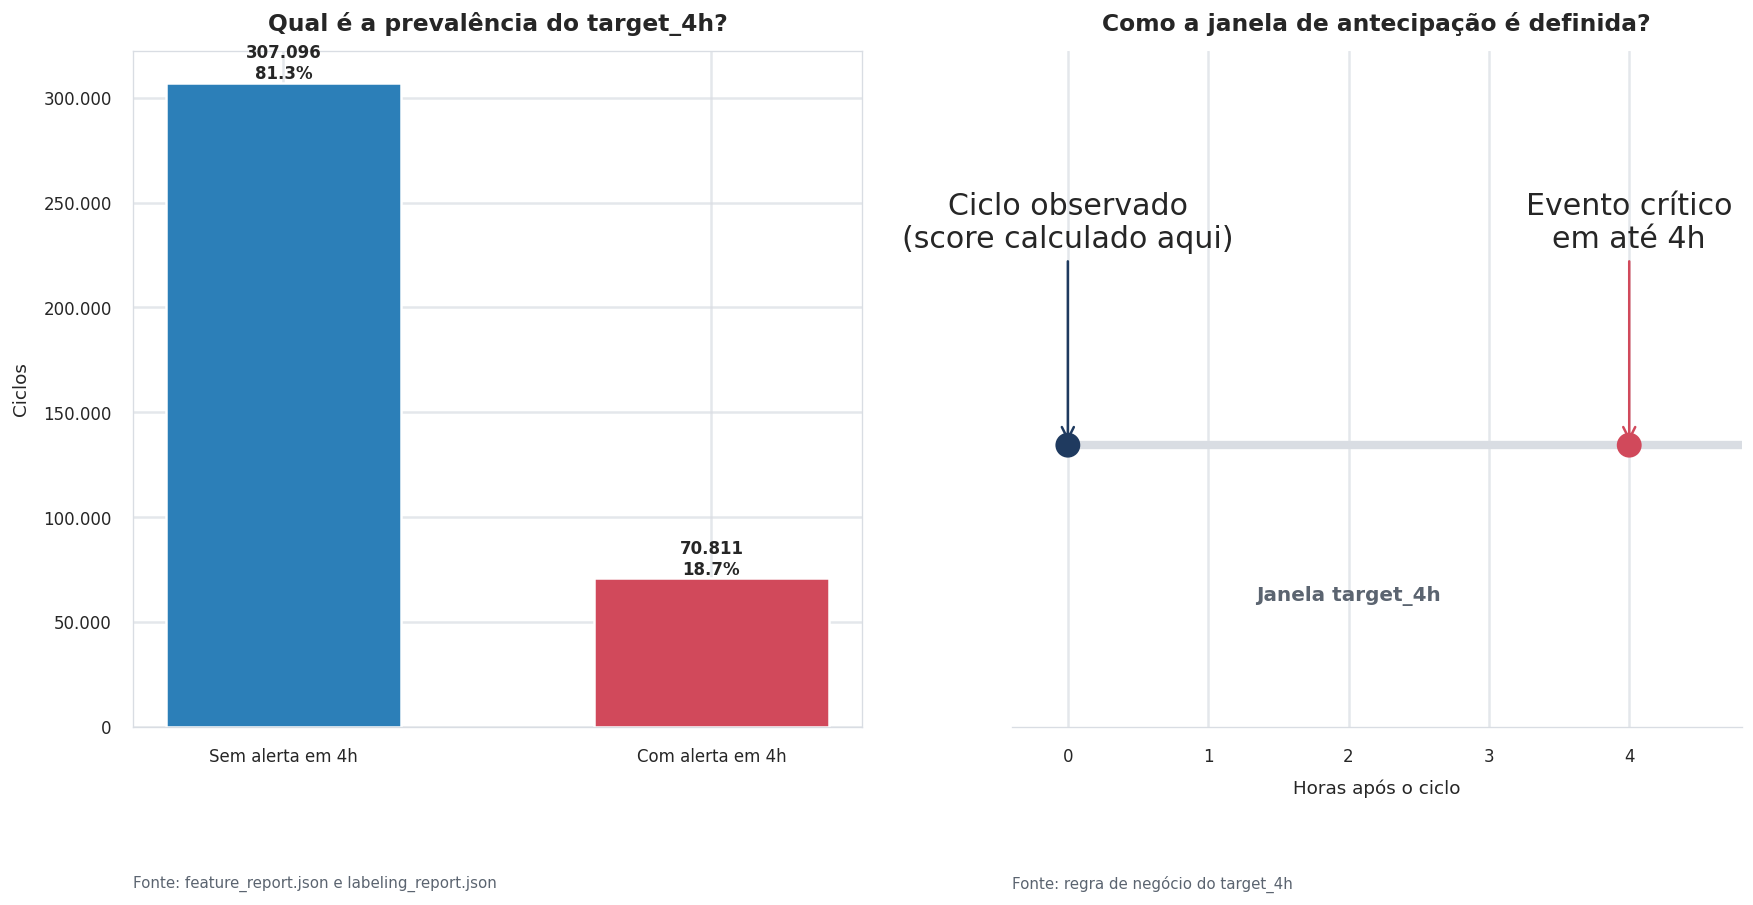

**Insight operacional:** a taxa positiva de `18.74%` indica desbalanceamento moderado; por isso a avaliação principal usa ranking TopK, não apenas acurácia ciclo-a-ciclo.

In [45]:
target_counts = features_df["target_4h"].value_counts().reindex([0, 1], fill_value=0)
target_rate = target_counts.loc[1] / target_counts.sum()

label_cards = pd.DataFrame([
    {"Indicador": "Eventos críticos finais", "Valor": fmt_int(labeling_json["rows_critical_events_final"])},
    {"Indicador": "Tags com sobreposição", "Valor": fmt_int(labeling_json["tag_overlap_count"])},
    {"Indicador": "Ciclos positivos target_4h", "Valor": f"{fmt_int(labeling_json['target_4h_positives'])} ({labeling_json['target_4h_positive_rate_pct']:.2f}%)"},
    {"Indicador": "Janela de antecipação", "Valor": "4 horas"},
    {"Indicador": "Cobertura de eventos críticos", "Valor": f"{labeling_json['critical_events_time_min']} a {labeling_json['critical_events_time_max']}"},
])
display(label_cards.style.hide(axis="index").set_caption("Resumo da rotulação supervisionada temporal"))

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

ax = axes[0]
bars = ax.bar(["Sem alerta em 4h", "Com alerta em 4h"], target_counts.values, color=[PALETTE["blue"], PALETTE["red"]], width=0.55)
for bar, value in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, value, f"{fmt_int(value)}\n{value/target_counts.sum():.1%}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_title("Qual é a prevalência do target_4h?")
ax.set_ylabel("Ciclos")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
add_source_note(ax, "Fonte: feature_report.json e labeling_report.json")

ax = axes[1]
ax.hlines(0, 0, 5, color=PALETTE["gray"], linewidth=5)
ax.scatter([0, 4], [0, 0], s=[180, 180], color=[PALETTE["navy"], PALETTE["red"]], zorder=3)
ax.annotate("Ciclo observado\n(score calculado aqui)", xy=(0, 0), xytext=(0, 0.35), ha="center", arrowprops=dict(arrowstyle="->", color=PALETTE["navy"]))
ax.annotate("Evento crítico\nem até 4h", xy=(4, 0), xytext=(4, 0.35), ha="center", arrowprops=dict(arrowstyle="->", color=PALETTE["red"]))
ax.text(2, -0.25, "Janela target_4h", ha="center", va="top", fontsize=12, fontweight="bold", color=PALETTE["slate"])
ax.set_xlim(-0.4, 4.8)
ax.set_ylim(-0.5, 0.7)
ax.set_xticks([0, 1, 2, 3, 4])
ax.set_xlabel("Horas após o ciclo")
ax.set_yticks([])
ax.set_title("Como a janela de antecipação é definida?")
ax.spines[["left", "right", "top"]].set_visible(False)
add_source_note(ax, "Fonte: regra de negócio do target_4h")

plt.tight_layout()
plt.show()

display(Markdown(f"**Insight operacional:** a taxa positiva de `{target_rate:.2%}` indica desbalanceamento moderado; por isso a avaliação principal usa ranking TopK, não apenas acurácia ciclo-a-ciclo."))

## 4. EDA Orientada à Decisão

A EDA precisa responder se existe sinal suficiente para priorizar equipamentos antes de alertas críticos. A análise combina dinâmica temporal, concentração operacional e sinais numéricos associados ao risco.


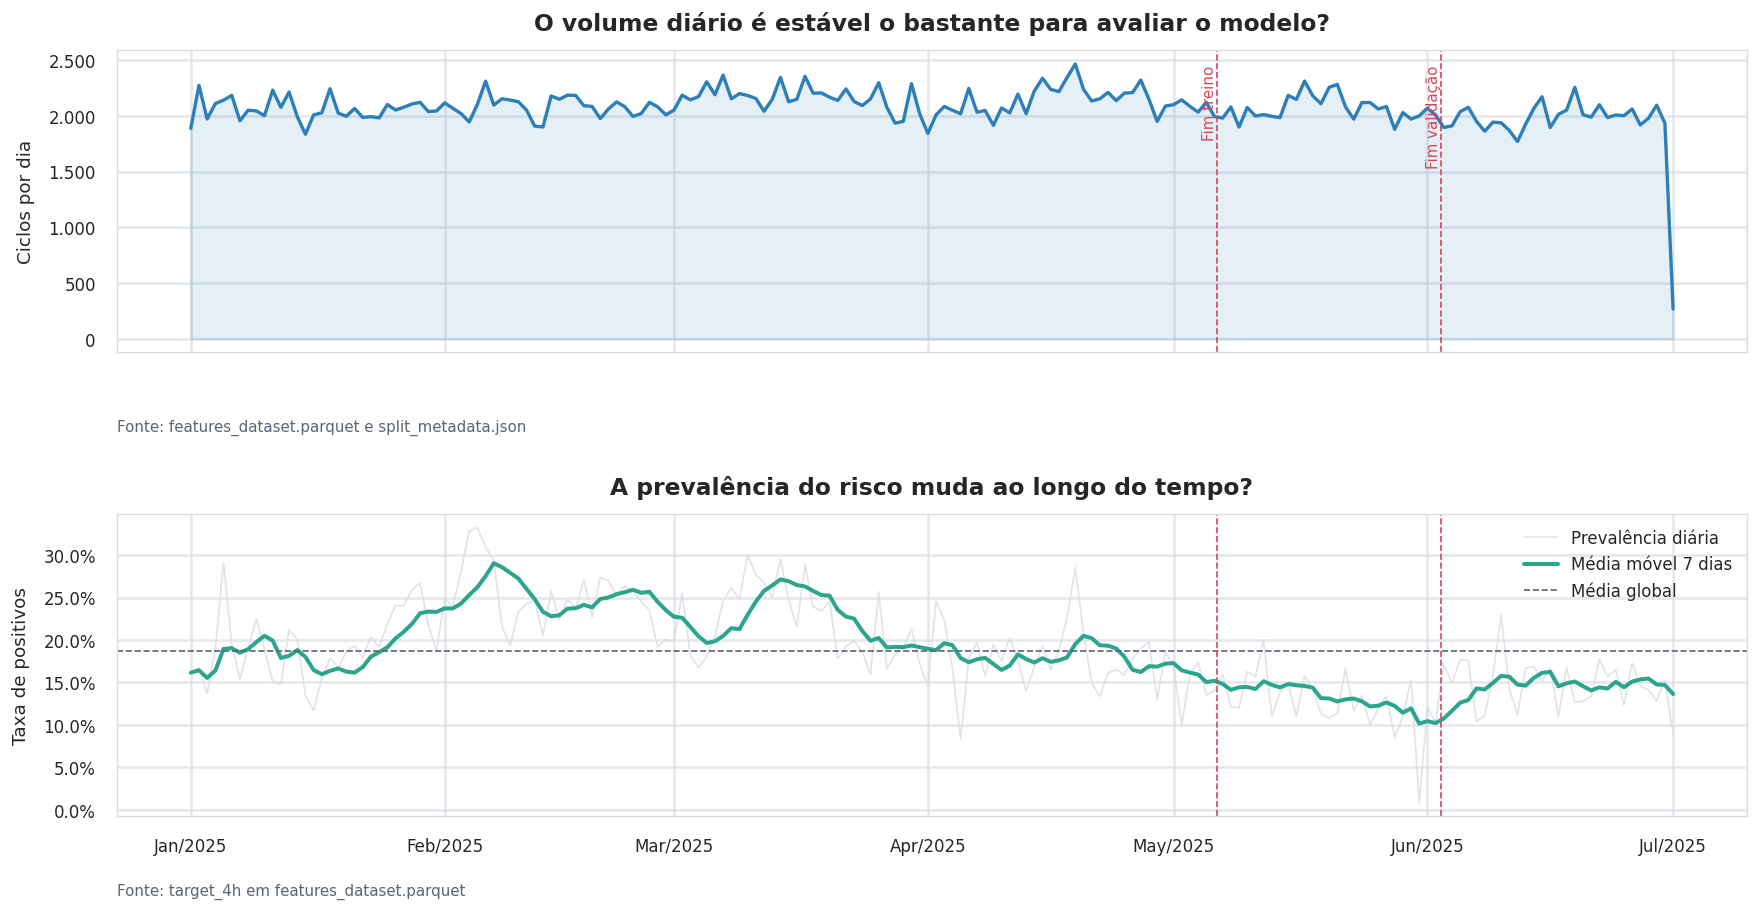

**Insight operacional:** há variação temporal relevante na prevalência; preservar a ordem cronológica no treino e na avaliação é obrigatório para evitar otimismo artificial.

In [46]:
daily = features_df.groupby("dia").agg(ciclos=("Id", "count"), prevalencia=("target_4h", "mean")).reset_index()
split_dates = {
    "Fim treino": pd.to_datetime(split_json["train_end"], utc=True),
    "Fim validação": pd.to_datetime(split_json["val_end"], utc=True),
}

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

ax = axes[0]
ax.plot(daily["dia"], daily["ciclos"], color=PALETTE["blue"], linewidth=2)
ax.fill_between(daily["dia"], daily["ciclos"], color=PALETTE["blue"], alpha=0.12)
ax.set_title("O volume diário é estável o bastante para avaliar o modelo?")
ax.set_ylabel("Ciclos por dia")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
for label, date in split_dates.items():
    ax.axvline(date, color=PALETTE["red"], linestyle="--", linewidth=1)
    ax.text(date, ax.get_ylim()[1] * 0.95, label, rotation=90, va="top", ha="right", fontsize=9, color=PALETTE["red"])
add_source_note(ax, "Fonte: features_dataset.parquet e split_metadata.json")

ax = axes[1]
roll_prev = daily["prevalencia"].rolling(7, min_periods=1).mean()
ax.plot(daily["dia"], daily["prevalencia"], color=PALETTE["gray"], linewidth=1, alpha=0.8, label="Prevalência diária")
ax.plot(daily["dia"], roll_prev, color=PALETTE["teal"], linewidth=2.4, label="Média móvel 7 dias")
ax.axhline(features_df["target_4h"].mean(), color=PALETTE["slate"], linestyle="--", linewidth=1, label="Média global")
for label, date in split_dates.items():
    ax.axvline(date, color=PALETTE["red"], linestyle="--", linewidth=1)
ax.set_title("A prevalência do risco muda ao longo do tempo?")
ax.set_ylabel("Taxa de positivos")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="upper right")
add_source_note(ax, "Fonte: target_4h em features_dataset.parquet")

axes[1].xaxis.set_major_locator(mdates.MonthLocator())
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))
plt.tight_layout()
plt.show()

display(Markdown("**Insight operacional:** há variação temporal relevante na prevalência; preservar a ordem cronológica no treino e na avaliação é obrigatório para evitar otimismo artificial."))

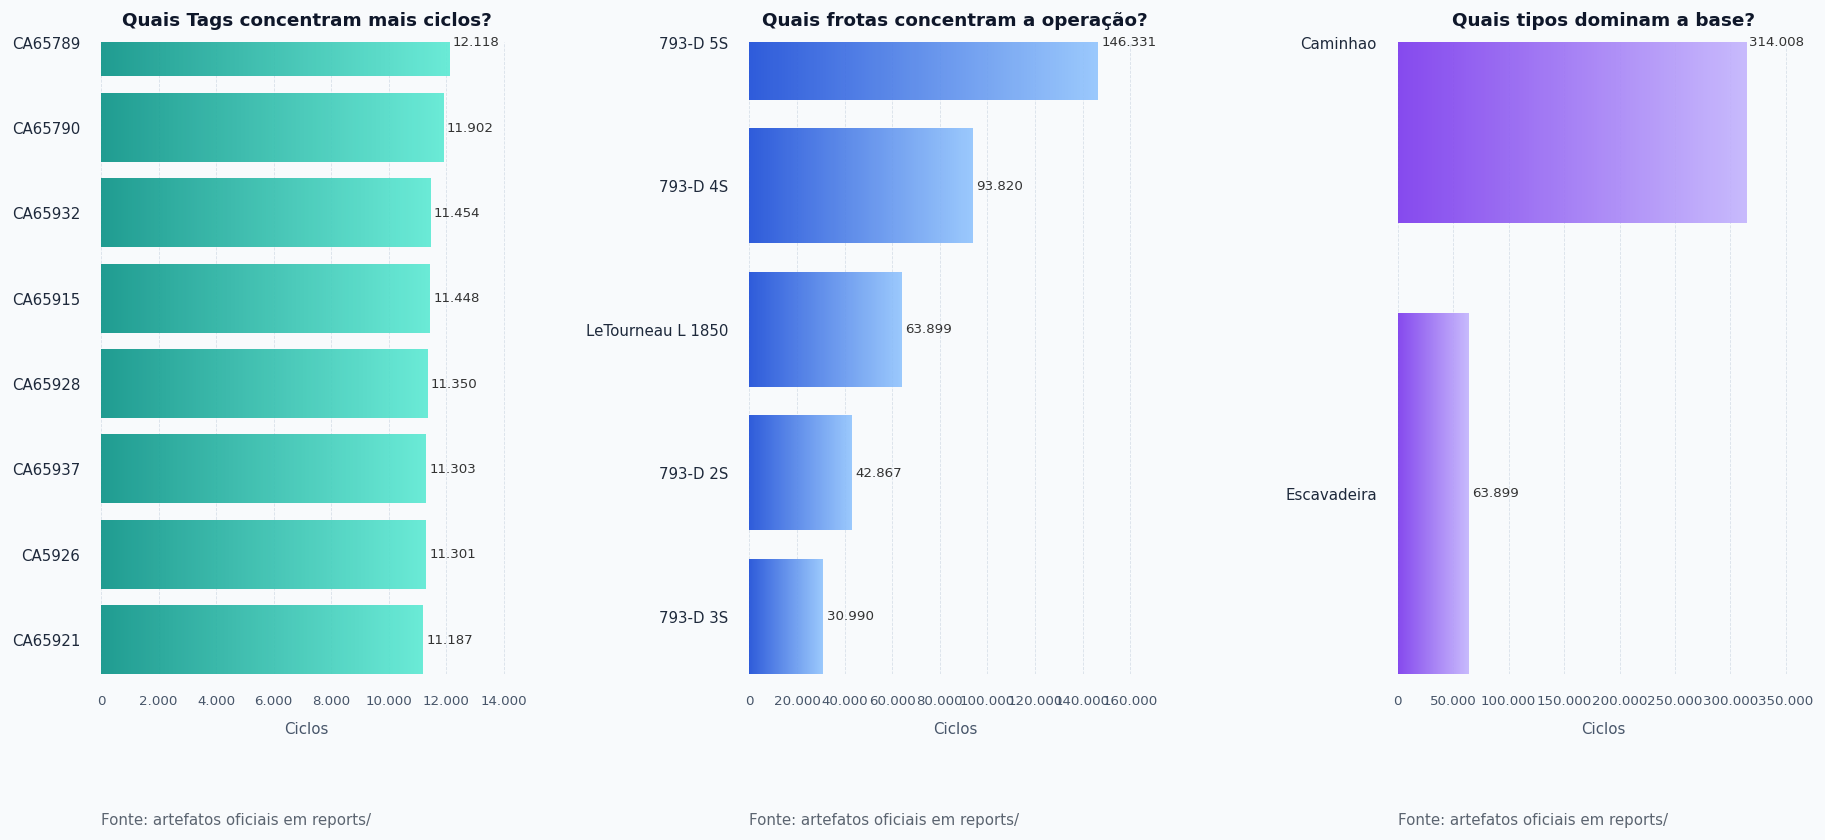

In [49]:
def pareto_table(series, top=10):
    counts = series.fillna("desconhecido").astype(str).value_counts().head(top)
    out = counts.rename_axis("categoria").reset_index(name="ciclos")
    out["participação"] = out["ciclos"] / len(series)
    out["participação_acumulada"] = out["participação"].cumsum()
    return out


def add_gradient_bars(ax, table, color_start, color_end, orientation="h"):
    """Substitui as barras sólidas por barras com degradê horizontal."""
    ax.cla()  # limpa barras antigas

    n = len(table)
    categorias = table["categoria"].tolist()
    valores = table["ciclos"].tolist()
    max_val = max(valores) if valores else 1

    for i, (cat, val) in enumerate(zip(categorias, valores)):
        # degradê da esquerda (color_start) para a direita (color_end)
        grad = np.linspace(0, 1, 256).reshape(1, -1)
        cmap = mcolors.LinearSegmentedColormap.from_list("grad", [color_start, color_end])

        extent = [0, val, i - 0.4, i + 0.4]
        ax.imshow(
            grad,
            aspect="auto",
            extent=extent,
            cmap=cmap,
            alpha=0.92,
            zorder=2,
        )
        # borda sutil
        rect = mpatches.FancyBboxPatch(
            (0, i - 0.4), val, 0.8,
            boxstyle="round,pad=0.01",
            linewidth=0,
            facecolor="none",
            edgecolor="none",
            zorder=3,
        )
        ax.add_patch(rect)

    ax.set_yticks(range(n))
    ax.set_yticklabels(categorias)
    ax.set_xlim(0, max_val * 1.18)
    ax.invert_yaxis()

    # labels de valor
    for i, val in enumerate(valores):
        ax.text(
            val + max_val * 0.01, i,
            fmt_int(val),
            va="center", ha="left",
            fontsize=8, color="#333333", zorder=5,
        )


import matplotlib.colors as mcolors

# ── Paleta de degradês ──────────────────────────────────────────────────────
GRADIENT_CONFIGS = [
    ("#0d9488", "#5eead4"),   # teal escuro → teal claro  (Tags)
    ("#1d4ed8", "#93c5fd"),   # azul escuro → azul claro  (Frotas)
    ("#7c3aed", "#c4b5fd"),   # roxo escuro → roxo claro  (Tipos)
]

fig, axes = plt.subplots(1, 3, figsize=(16, 8))
fig.patch.set_facecolor("#f8fafc")

paretos = [
    ("Tag" if "Tag" in features_df.columns else None, "Quais Tags concentram mais ciclos?"),
    ("frota_decoded", "Quais frotas concentram a operação?"),
    ("tipo_decoded",  "Quais tipos dominam a base?"),
]

for ax, (column, title), (c_start, c_end) in zip(axes, paretos, GRADIENT_CONFIGS):
    ax.set_facecolor("#f8fafc")

    if column is None:
        ax.axis("off")
        ax.text(
            0.5, 0.5,
            "Tag não disponível\nna base de features",
            ha="center", va="center", fontsize=12, color="#64748b",
        )
        continue

    table = pareto_table(features_df[column], top=8)

    # barras com degradê
    add_gradient_bars(ax, table, c_start, c_end, orientation="h")

    # formatação dos eixos
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: fmt_int(x)))
    ax.tick_params(axis="x", labelsize=8, colors="#475569")
    ax.tick_params(axis="y", labelsize=9, colors="#1e293b")

    # grid leve
    ax.set_axisbelow(True)
    ax.xaxis.grid(True, color="#cbd5e1", linewidth=0.5, linestyle="--")
    ax.yaxis.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.set_title(title, fontsize=11, fontweight="bold", color="#0f172a", pad=10)
    ax.set_xlabel("Ciclos", fontsize=9, color="#475569")
    ax.set_ylabel("")

    add_source_note(ax)

plt.tight_layout(pad=2.0)
plt.show()

## 5. Feature Engineering e Prevenção de Vazamento

O modelo só pode usar informações disponíveis até o momento do ciclo. Variáveis que apontam diretamente para o futuro são mantidas para auditoria/rotulação, mas removidas da matriz modelável.


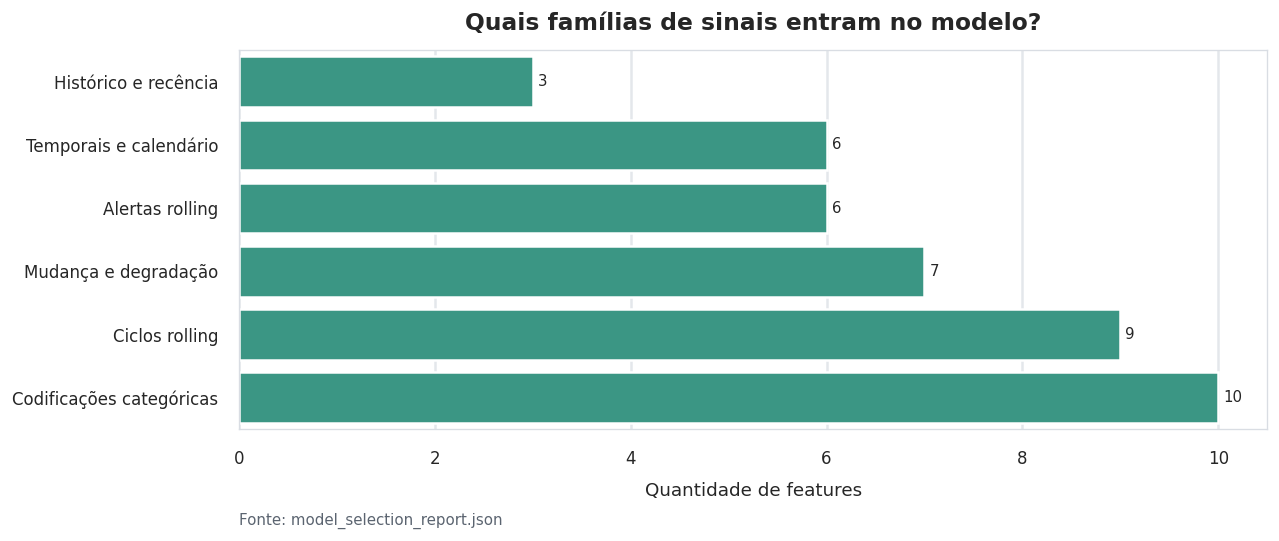

Família,Qtd. features,Exemplos
Codificações categóricas,10,"Tag_freq, Operador_freq, Classe_target_enc, Frota_793-D 2S"
Ciclos rolling,9,"n_ciclos_4h, duracao_media_ciclo_4h, duracao_std_ciclo_4h, n_ciclos_8h"
Mudança e degradação,7,"delta_duracao_ciclo_4h_24h, ratio_duracao_ciclo_4h_24h, delta_alertas_por_hora_4h_24h, ratio_alertas_4h_24h"
Temporais e calendário,6,"hora_do_dia, dia_da_semana, mes, is_fim_de_semana"
Alertas rolling,6,"n_alertas_4h, alertas_por_hora_4h, n_alertas_8h, alertas_por_hora_8h"
Histórico e recência,3,"dias_desde_ultimo_alerta, n_precondicoes_satisfeitas_4h, nivel_maximo_evento_recente"


Coluna removida,Motivo
Classe,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
Fim,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
Id,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
Inicio,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
Tag,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
next_critical_event_time,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
target_4h,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
tte_horas,"Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"


feature,importance
dias_desde_ultimo_alerta,6763
Tag_freq,5670
duracao_std_ciclo_24h,1496
dia_da_semana,1201
hora_do_dia,1085
duracao_media_ciclo_24h,952
n_ciclos_24h,904
Classe_target_enc,787


**Insight operacional:** o modelo aprende padrões recentes e históricos sem usar `tte_horas`, `next_critical_event_time` ou o próprio `target_4h` como entrada.

In [53]:
feature_columns = selection_json["feature_columns"]
leakage_columns = selection_json.get("leakage_columns", [])
all_cols = features_df.columns.tolist()

families = {
    "Temporais e calendário": [c for c in feature_columns if c in {"hora_do_dia", "dia_da_semana", "mes", "is_fim_de_semana", "hora", "dia_semana"}],
    "Ciclos rolling": [c for c in feature_columns if c.startswith("n_ciclos_") or c.startswith("duracao_media") or c.startswith("duracao_std")],
    "Alertas rolling": [c for c in feature_columns if c.startswith("n_alertas_") or c.startswith("alertas_por_hora")],
    "Mudança e degradação": [c for c in feature_columns if c.startswith("delta_") or c.startswith("ratio_")],
    "Histórico e recência": [c for c in feature_columns if c in {"dias_desde_ultimo_alerta", "nivel_maximo_evento_recente", "n_precondicoes_satisfeitas_4h"}],
    "Codificações categóricas": [c for c in feature_columns if c.endswith("_freq") or c.endswith("_target_enc") or c.startswith("Frota_") or c.startswith("Tipo_")],
}

family_df = pd.DataFrame([
    {"Família": family, "Qtd. features": len(cols), "Exemplos": ", ".join(cols[:4])}
    for family, cols in families.items()
]).sort_values("Qtd. features", ascending=True)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=family_df, y="Família", x="Qtd. features", color=PALETTE["teal"], ax=ax)
ax.set_title("Quais famílias de sinais entram no modelo?")
ax.set_xlabel("Quantidade de features")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, fmt="%.0f", fontsize=9, padding=3)
add_source_note(ax, "Fonte: model_selection_report.json")
plt.tight_layout()
plt.show()

display(family_df.sort_values("Qtd. features", ascending=False).style.hide(axis="index").set_caption("Famílias de features modeláveis"))

leakage_df = pd.DataFrame({
    "Coluna removida": leakage_columns,
    "Motivo": [
        "Informação futura, alvo, identificador bruto ou timestamp/categoria substituída por feature histórica"
        for _ in leakage_columns
    ],
})
display(leakage_df.style.hide(axis="index").set_caption("Controles contra vazamento de informação"))

importance_preview = feature_importance_df.head(8).copy()
if {"feature", "importance"}.issubset(importance_preview.columns):
    display(importance_preview.style.hide(axis="index").format({"importance": "{:.0f}"}).set_caption("Top features do artefato selecionado"))

display(Markdown("**Insight operacional:** o modelo aprende padrões recentes e históricos sem usar `tte_horas`, `next_critical_event_time` ou o próprio `target_4h` como entrada."))

## 6. Treinamento e Seleção Robusta

A seleção oficial compara quatro famílias supervisionadas com Optuna, mesma base, mesmo split temporal e mesma métrica operacional. O teste temporal fica reservado para reporte final, não para escolher modelo.

**Regra oficial:** maior `val_top15_recall_at_k`; desempates por `val_top15_precision_at_k`, `val_top15_lift_vs_random` e `val_auc_pr`.


Modelo,Papel,Estimador,Treino (s),Val Recall@15,Val Precision@15,Val Lift@15,Test Recall@15
lightgbm_optuna,official_candidate,LGBMClassifier,5.96,0.7574,0.6690,2.1460,0.7361
hist_gbdt_optuna,official_candidate,HistGradientBoostingClassifier,11.26,0.7547,0.6667,2.1384,0.7337
xgboost_optuna,official_candidate,XGBClassifier,6.20,0.7547,0.6667,2.1384,0.7433
extra_trees_optuna,official_candidate,Pipeline,28.63,0.7143,0.6310,2.0238,0.6998
logistic_regression_baseline,diagnostic_baseline,Pipeline,1.94,0.7062,0.6238,2.0009,0.7337


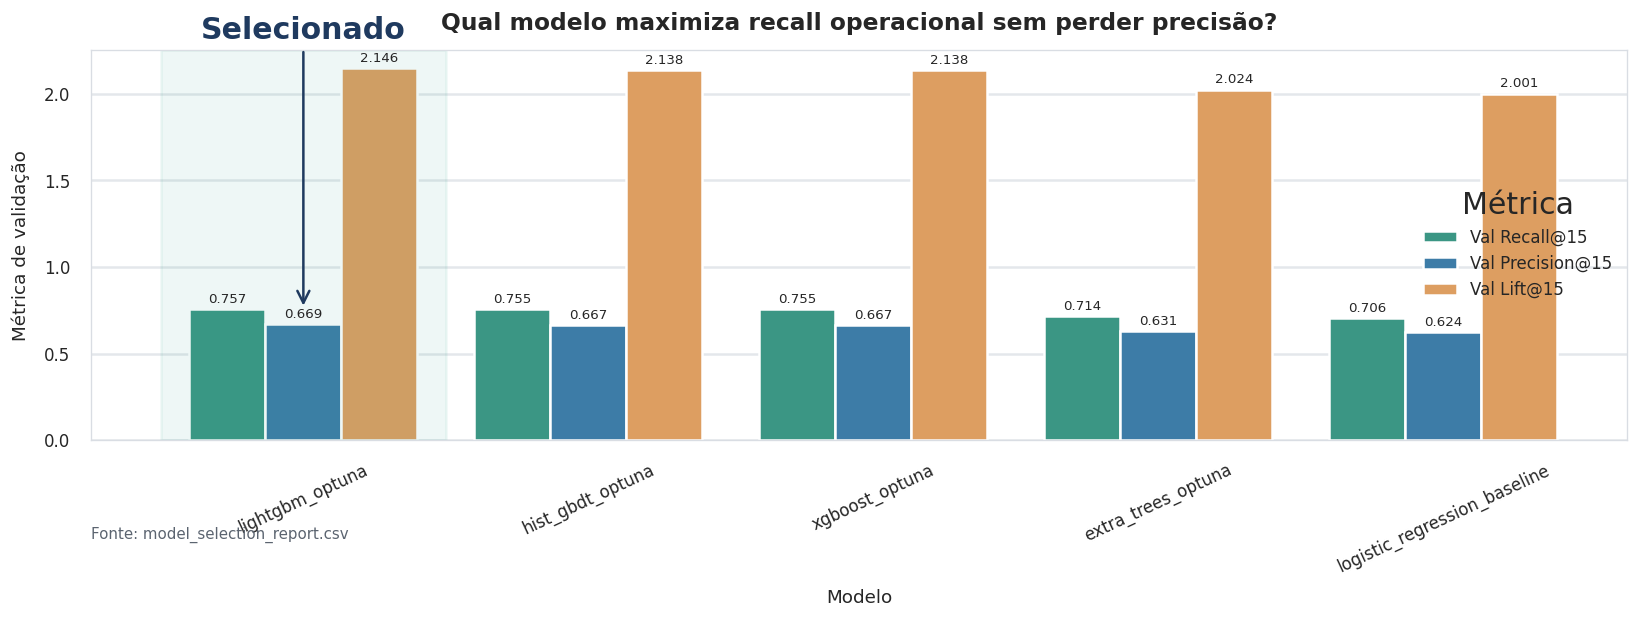

Fold,Test Precision@15,Test Recall@15,Test Lift@15
1,0.6877,0.7538,2.1769
2,0.6281,0.7306,2.0585
3,0.6600,0.7174,2.0326


**Insight operacional:** `lightgbm_optuna` vence pela regra de validação, com Recall@15 de `0.7574` e Lift@15 de `2.15x`. O baseline `logistic_regression_baseline` permanece apenas como referência diagnóstica.

In [54]:
official_candidates = selection_json.get("official_candidates", [])
diagnostic_baseline = selection_json.get("diagnostic_baseline", "logistic_regression_baseline")

candidate_table = selection_df[["model_name", "role", "estimator", "fit_seconds", "val_top15_recall_at_k", "val_top15_precision_at_k", "val_top15_lift_vs_random", "test_top15_recall_at_k"]].copy()
candidate_table = candidate_table.sort_values(["val_top15_recall_at_k", "val_top15_precision_at_k", "val_top15_lift_vs_random"], ascending=False)

display(
    candidate_table.rename(columns={
        "model_name": "Modelo", "role": "Papel", "estimator": "Estimador", "fit_seconds": "Treino (s)",
        "val_top15_recall_at_k": "Val Recall@15", "val_top15_precision_at_k": "Val Precision@15",
        "val_top15_lift_vs_random": "Val Lift@15", "test_top15_recall_at_k": "Test Recall@15",
    }).style.hide(axis="index").format({"Treino (s)": "{:.2f}", "Val Recall@15": "{:.4f}", "Val Precision@15": "{:.4f}", "Val Lift@15": "{:.4f}", "Test Recall@15": "{:.4f}"}).set_caption("Comparação de candidatos pela regra oficial")
)

plot_df = candidate_table.melt(
    id_vars="model_name",
    value_vars=["val_top15_recall_at_k", "val_top15_precision_at_k", "val_top15_lift_vs_random"],
    var_name="metric",
    value_name="value",
)
metric_labels = {
    "val_top15_recall_at_k": "Val Recall@15",
    "val_top15_precision_at_k": "Val Precision@15",
    "val_top15_lift_vs_random": "Val Lift@15",
}
plot_df["metric"] = plot_df["metric"].map(metric_labels)

fig, ax = plt.subplots(figsize=(14, 5.5))
sns.barplot(data=plot_df, x="model_name", y="value", hue="metric", palette=[PALETTE["teal"], PALETTE["blue"], PALETTE["orange"]], ax=ax)
ax.set_title("Qual modelo maximiza recall operacional sem perder precisão?")
ax.set_xlabel("Modelo")
ax.set_ylabel("Métrica de validação")
ax.tick_params(axis="x", rotation=25)
idx = candidate_table["model_name"].tolist().index(model_name)
ax.axvspan(idx - 0.5, idx + 0.5, color=PALETTE["teal"], alpha=0.08)
ax.annotate("Selecionado", xy=(idx, candidate_table.iloc[0]["val_top15_recall_at_k"]), xytext=(idx, plot_df["value"].max() * 1.08), ha="center", arrowprops=dict(arrowstyle="->", color=PALETTE["navy"]), color=PALETTE["navy"], fontweight="bold")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
ax.legend(title="Métrica")
add_source_note(ax, "Fonte: model_selection_report.csv")
plt.tight_layout()
plt.show()

backtest_summary = backtest_df[["fold", "test_top15_precision_at_k", "test_top15_recall_at_k", "test_top15_lift_vs_random"]].copy()
display(backtest_summary.rename(columns={"fold": "Fold", "test_top15_precision_at_k": "Test Precision@15", "test_top15_recall_at_k": "Test Recall@15", "test_top15_lift_vs_random": "Test Lift@15"}).style.hide(axis="index").format(precision=4).set_caption("Backtesting temporal do modelo selecionado"))

display(Markdown(
    f"**Insight operacional:** `{model_name}` vence pela regra de validação, com "
    f"Recall@15 de `{selected_model['val_top15_recall_at_k']:.4f}` e Lift@15 de `{selected_model['val_top15_lift_vs_random']:.2f}x`. "
    f"O baseline `{diagnostic_baseline}` permanece apenas como referência diagnóstica."
))

## 7. Threshold Técnico e Diagnóstico Ciclo-a-Ciclo

O modelo gera um score de risco entre 0 e 1. O threshold oficial é calibrado na validação e usado para diagnóstico técnico ciclo-a-ciclo. A decisão operacional principal continua sendo o ranking **Top15 Tag-dia**.


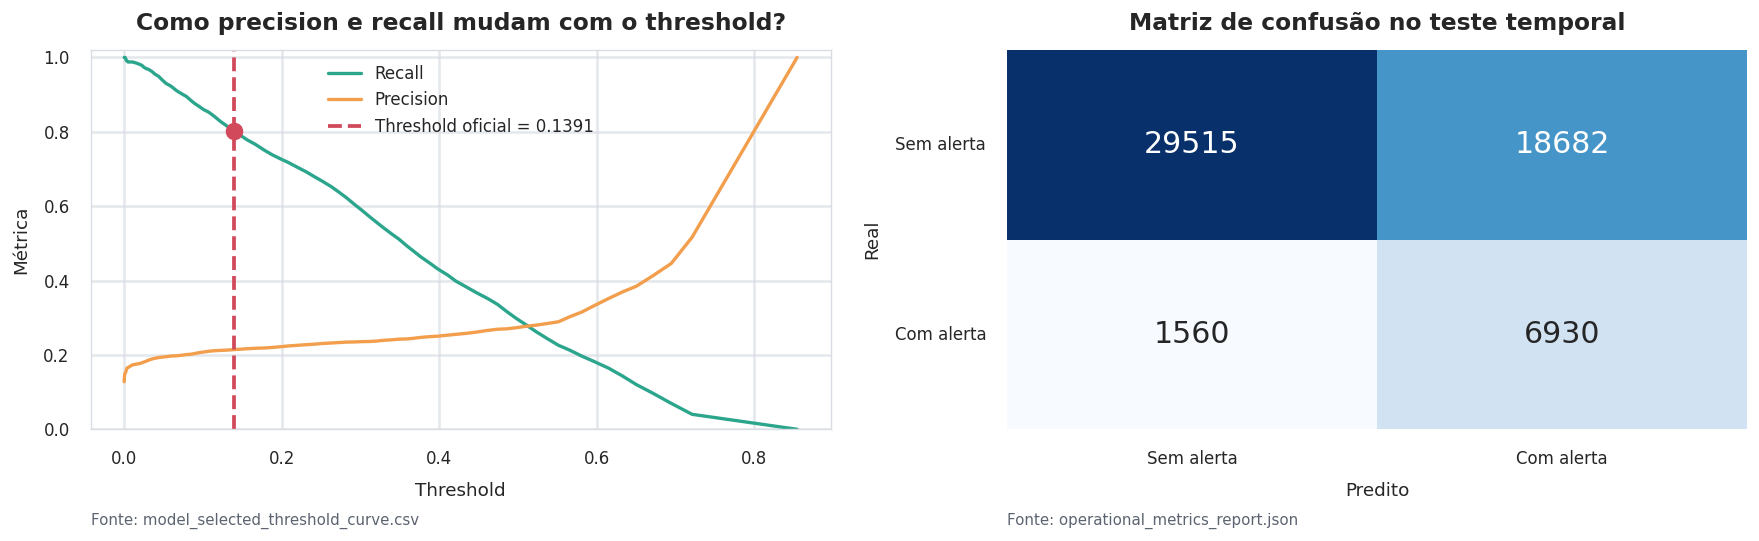

Split,Threshold,Precision,Recall,Preditos positivos,% predito positivo
Teste,0.139074,0.2706,0.8163,25.612,45.2%


**Insight operacional:** o threshold `0.139074` mantém recall técnico alto (`0.816`), mas o volume ciclo-a-ciclo é grande; por isso a rotina de campo deve usar Top15 Tag-dia.

In [55]:
curve = threshold_curve_df.copy()
closest_idx = (curve["threshold"] - threshold).abs().idxmin()
selected_threshold_row = curve.loc[closest_idx]
rows = int(threshold_test["rows"])
tp = int(threshold_test["true_positive"])
fp = int(threshold_test["false_positive"])
fn = int(threshold_test["false_negative"])
tn = rows - tp - fp - fn
cm = np.array([[tn, fp], [fn, tp]])

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
ax.plot(curve["threshold"], curve["recall"], label="Recall", color=PALETTE["teal"], linewidth=2)
ax.plot(curve["threshold"], curve["precision"], label="Precision", color=PALETTE["orange"], linewidth=2)
ax.axvline(threshold, color=PALETTE["red"], linestyle="--", label=f"Threshold oficial = {threshold:.4f}")
ax.scatter([threshold], [selected_threshold_row["recall"]], color=PALETTE["red"], zorder=4)
ax.set_title("Como precision e recall mudam com o threshold?")
ax.set_xlabel("Threshold")
ax.set_ylabel("Métrica")
ax.set_ylim(0, 1.02)
ax.legend()
add_source_note(ax, "Fonte: model_selected_threshold_curve.csv")

ax = axes[1]
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
ax.set_title("Matriz de confusão no teste temporal")
ax.set_xlabel("Predito")
ax.set_ylabel("Real")
ax.set_xticklabels(["Sem alerta", "Com alerta"])
ax.set_yticklabels(["Sem alerta", "Com alerta"], rotation=0)
add_source_note(ax, "Fonte: operational_metrics_report.json")

plt.tight_layout()
plt.show()

threshold_table = pd.DataFrame([{
    "Split": "Teste",
    "Threshold": threshold,
    "Precision": threshold_test["precision"],
    "Recall": threshold_test["recall"],
    "Preditos positivos": threshold_test["predicted_positive"],
    "% predito positivo": threshold_test["predicted_positive_rate"],
}])
display(threshold_table.style.hide(axis="index").format({"Threshold": "{:.6f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "Preditos positivos": lambda v: fmt_int(v), "% predito positivo": "{:.1%}"}).set_caption("Diagnóstico técnico ciclo-a-ciclo"))

display(Markdown(f"**Insight operacional:** o threshold `{threshold:.6f}` mantém recall técnico alto (`{threshold_test['recall']:.3f}`), mas o volume ciclo-a-ciclo é grande; por isso a rotina de campo deve usar Top15 Tag-dia."))

## 8. Resultado Operacional: Top15 Tag-dia

Esta é a avaliação central do projeto. Para cada dia, o modelo ordena as `Tags` por risco e mede a qualidade dos primeiros equipamentos da lista.

Top15 traduz o modelo em capacidade operacional: uma lista curta, diária e auditável para inspeção preventiva.


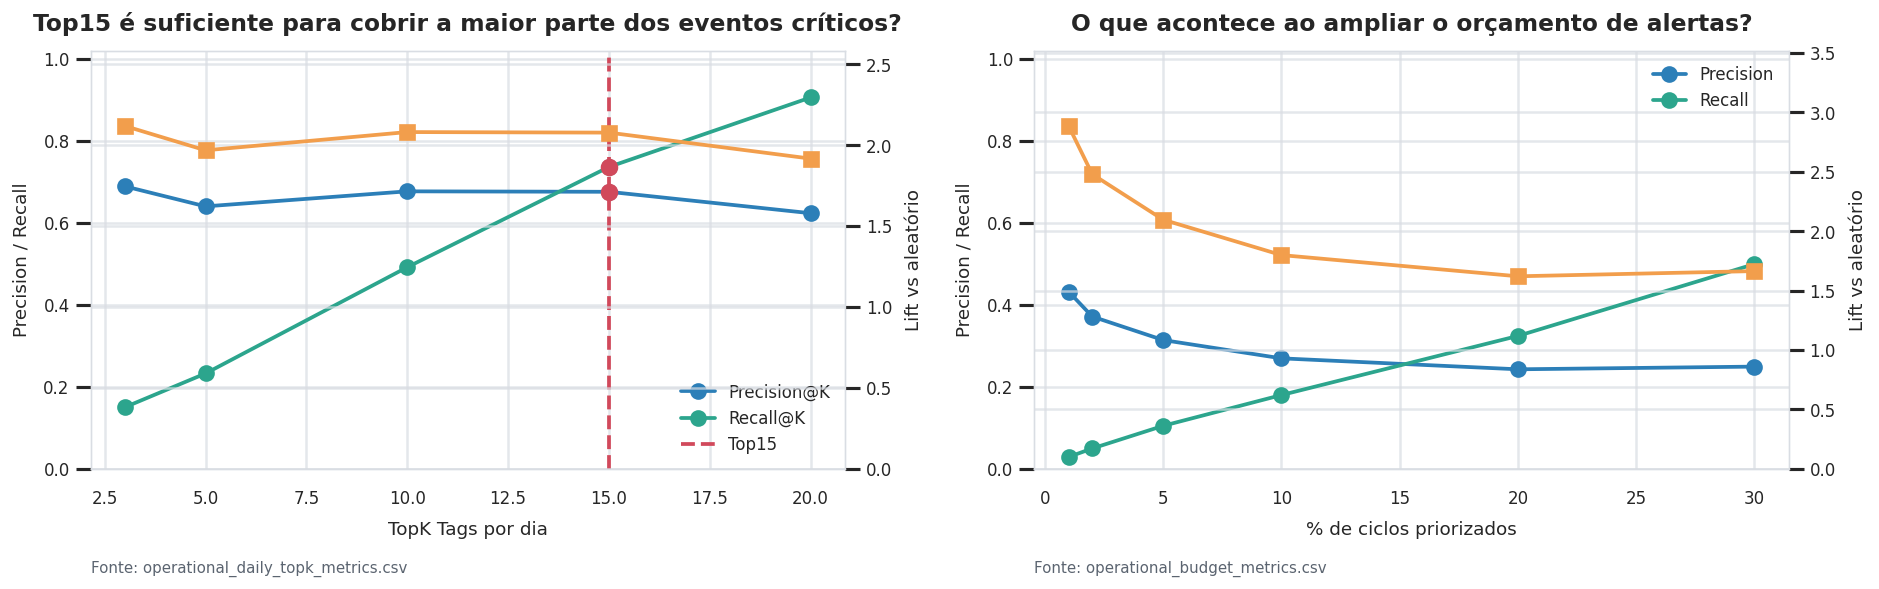

Lista diária,Dias avaliados,Equipamentos/dia,Positivos capturados,Precision@15,Recall@15,Lift@15
Top15 Tag-dia,30,15,304 de 413,0.6756,0.7361,2.0774x


TopK,Alertas/dia,Precision,Recall,Lift,Capturados,Total positivos
3,3.0,0.6889,0.1501,2.1184x,62,413
5,5.0,0.6400,0.2324,1.9680x,96,413
10,10.0,0.6767,0.4915,2.0808x,203,413
15,15.0,0.6756,0.7361,2.0774x,304,413
20,20.0,0.6233,0.9056,1.9168x,374,413


**Insight operacional:** no teste temporal, Top15 captura `304` de `413` Tag-dias positivos, com Precision@15 `0.676` e Lift `2.08x` sobre escolha aleatória.

In [56]:
topk = oper_topk_df.query("split == 'test'").sort_values("top_k_tags_per_day").copy()
budget = oper_budget_df.query("split == 'test'").sort_values("budget_pct").copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.4))

ax = axes[0]
ax.plot(topk["top_k_tags_per_day"], topk["precision_at_k"], marker="o", color=PALETTE["blue"], label="Precision@K")
ax.plot(topk["top_k_tags_per_day"], topk["recall_at_k"], marker="o", color=PALETTE["teal"], label="Recall@K")
ax.axvline(15, color=PALETTE["red"], linestyle="--", label="Top15")
ax.scatter([15, 15], [topk15["precision_at_k"], topk15["recall_at_k"]], color=PALETTE["red"], zorder=4)
ax.set_title("Top15 é suficiente para cobrir a maior parte dos eventos críticos?")
ax.set_xlabel("TopK Tags por dia")
ax.set_ylabel("Precision / Recall")
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
add_source_note(ax, "Fonte: operational_daily_topk_metrics.csv")

ax_lift = ax.twinx()
ax_lift.plot(topk["top_k_tags_per_day"], topk["lift_vs_random"], marker="s", color=PALETTE["orange"], label="Lift@K")
ax_lift.set_ylabel("Lift vs aleatório")
ax_lift.set_ylim(0, topk["lift_vs_random"].max() * 1.22)

ax = axes[1]
ax.plot(budget["budget_pct"] * 100, budget["precision_at_budget"], marker="o", color=PALETTE["blue"], label="Precision")
ax.plot(budget["budget_pct"] * 100, budget["recall_at_budget"], marker="o", color=PALETTE["teal"], label="Recall")
ax.set_title("O que acontece ao ampliar o orçamento de alertas?")
ax.set_xlabel("% de ciclos priorizados")
ax.set_ylabel("Precision / Recall")
ax.set_ylim(0, 1.02)
ax.legend(loc="upper right")
add_source_note(ax, "Fonte: operational_budget_metrics.csv")

ax_lift = ax.twinx()
ax_lift.plot(budget["budget_pct"] * 100, budget["lift_vs_random"], marker="s", color=PALETTE["orange"], label="Lift")
ax_lift.set_ylabel("Lift vs aleatório")
ax_lift.set_ylim(0, budget["lift_vs_random"].max() * 1.22)

plt.tight_layout()
plt.show()

executive_topk = pd.DataFrame([{
    "Lista diária": "Top15 Tag-dia",
    "Dias avaliados": int(topk15["days"]),
    "Equipamentos/dia": int(topk15["alerts_per_day"]),
    "Positivos capturados": f"{fmt_int(topk15['positives_captured'])} de {fmt_int(topk15['total_positives'])}",
    "Precision@15": topk15["precision_at_k"],
    "Recall@15": topk15["recall_at_k"],
    "Lift@15": topk15["lift_vs_random"],
}])
display(executive_topk.style.hide(axis="index").format({"Precision@15": "{:.4f}", "Recall@15": "{:.4f}", "Lift@15": "{:.4f}x"}).set_caption("Resultado operacional no teste temporal"))

topk_table = topk[["top_k_tags_per_day", "alerts_per_day", "precision_at_k", "recall_at_k", "lift_vs_random", "positives_captured", "total_positives"]].copy()
display(topk_table.rename(columns={"top_k_tags_per_day": "TopK", "alerts_per_day": "Alertas/dia", "precision_at_k": "Precision", "recall_at_k": "Recall", "lift_vs_random": "Lift", "positives_captured": "Capturados", "total_positives": "Total positivos"}).style.hide(axis="index").format({"Alertas/dia": "{:.1f}", "Precision": "{:.4f}", "Recall": "{:.4f}", "Lift": "{:.4f}x"}).set_caption("Curva operacional TopK"))

display(Markdown(f"**Insight operacional:** no teste temporal, Top15 captura `{topk15['positives_captured']:.0f}` de `{topk15['total_positives']:.0f}` Tag-dias positivos, com Precision@15 `{topk15['precision_at_k']:.3f}` e Lift `{topk15['lift_vs_random']:.2f}x` sobre escolha aleatória."))

## 9. Segmentos e Riscos

O desempenho global precisa ser auditado por recortes operacionais. Segmentos inconclusivos por baixa prevalência não significam reprovação automática; eles indicam necessidade de monitoramento e coleta dedicada.


/var/folders/0q/hw9t6jv16lq6_3f63snxhlrm0000gn/T/ipykernel_9851/4277633968.py:47: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.imshow(grad, aspect="auto", extent=[0, va, y_a, y_a + bar_h],
/var/folders/0q/hw9t6jv16lq6_3f63snxhlrm0000gn/T/ipykernel_9851/4277633968.py:53: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.imshow(grad, aspect="auto", extent=[0, vb, y_b, y_b + bar_h],


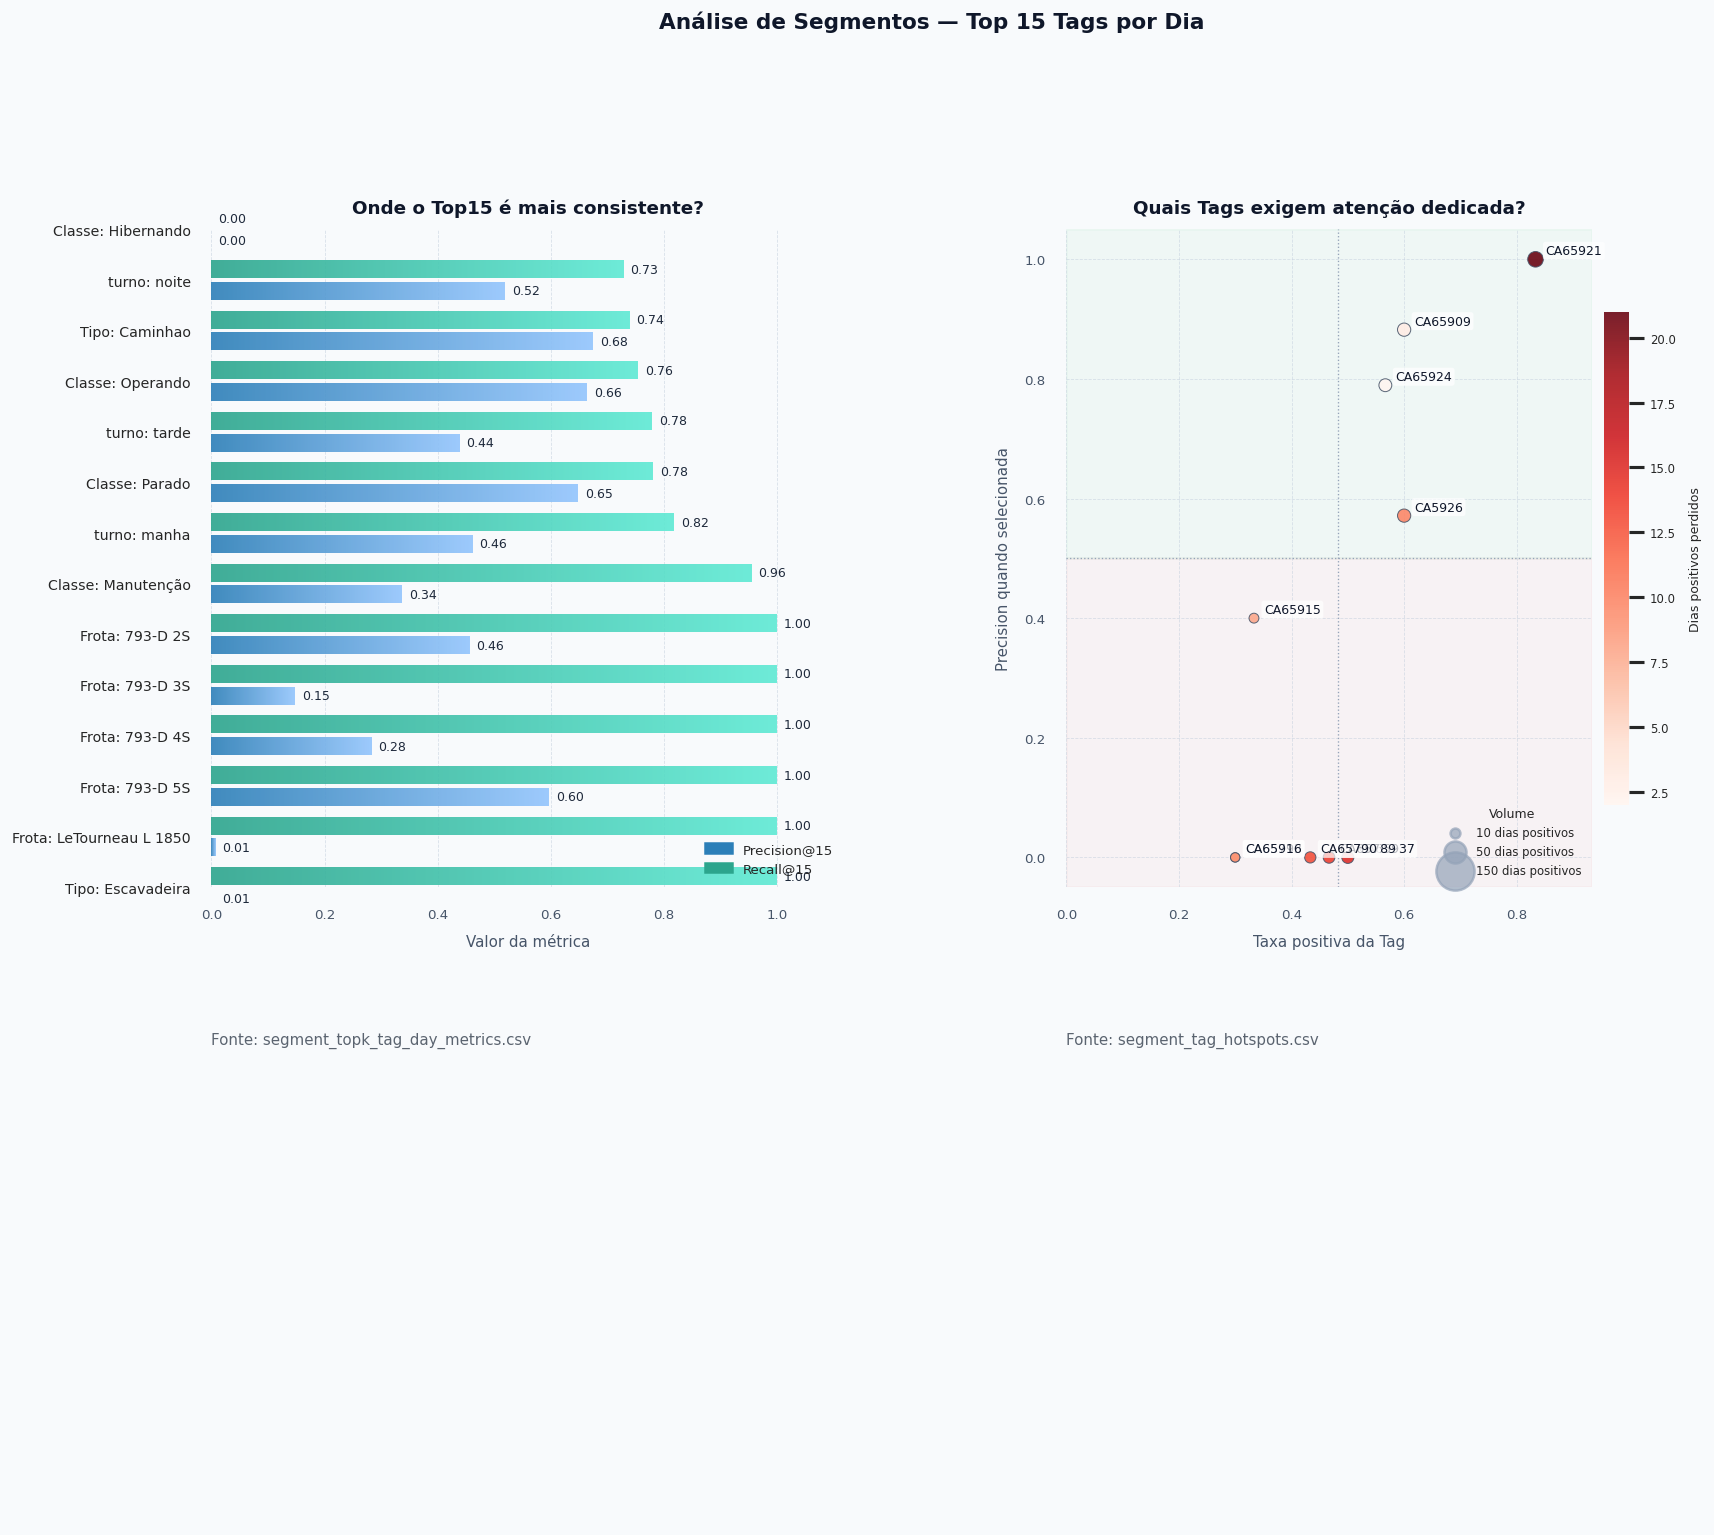

segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
turno,manha,15,1185,28,420,15.000,0.200,0.462,0.819,2.310,194,237,ok,usar TopK como canal principal
turno,tarde,15,1227,29,435,15.000,0.200,0.439,0.780,2.199,191,245,ok,usar TopK como canal principal
turno,noite,15,1267,30,450,15.000,0.253,0.520,0.729,2.052,234,321,ok,usar TopK como canal principal
Tipo,Caminhao,15,999,30,450,15.000,0.411,0.676,0.740,1.642,304,411,ok,usar TopK como canal principal
Classe,Parado,15,784,30,450,15.000,0.477,0.649,0.781,1.360,292,374,ok,usar TopK como canal principal
Classe,Operando,15,793,30,450,15.000,0.499,0.664,0.755,1.331,299,396,ok,usar TopK como canal principal
Classe,Manutenção,15,564,30,445,14.833,0.278,0.337,0.955,1.211,150,157,ok,usar TopK como canal principal
Frota,793-D 5S,15,390,30,390,13.000,0.597,0.597,1.000,1.000,233,233,ok,usar TopK como canal principal


segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
Classe,Hibernando,15,400,30,400,13.333,0.000,0.000,0.000,0.000,0,0,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
turno,noite,15,1267,30,450,15.000,0.253,0.520,0.729,2.052,234,321,ok,usar TopK como canal principal
Tipo,Caminhao,15,999,30,450,15.000,0.411,0.676,0.740,1.642,304,411,ok,usar TopK como canal principal
Classe,Operando,15,793,30,450,15.000,0.499,0.664,0.755,1.331,299,396,ok,usar TopK como canal principal
turno,tarde,15,1227,29,435,15.000,0.200,0.439,0.780,2.199,191,245,ok,usar TopK como canal principal
Classe,Parado,15,784,30,450,15.000,0.477,0.649,0.781,1.360,292,374,ok,usar TopK como canal principal
turno,manha,15,1185,28,420,15.000,0.200,0.462,0.819,2.310,194,237,ok,usar TopK como canal principal
Classe,Manutenção,15,564,30,445,14.833,0.278,0.337,0.955,1.211,150,157,ok,usar TopK como canal principal


segment_col,segment_value,top_k_tags_per_day,tag_days,days,selected_alerts,alerts_per_day,tag_day_prevalence,precision_at_k,recall_at_k,lift_vs_random,positives_captured,total_positives,status,recommendation
Classe,Hibernando,15,400,30,400,13.333,0.000,0.000,0.000,0.000,0,0,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
Frota,LeTourneau L 1850,15,271,30,271,9.033,0.007,0.007,1.000,1.000,2,2,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada
Tipo,Escavadeira,15,271,30,271,9.033,0.007,0.007,1.000,1.000,2,2,inconclusivo_baixa_prevalencia,tratar segmento em trilha separada


**Insight operacional:** a governança deve operar o piloto com trilha segmentada: usar o score global, monitorar frotas/tipos/Tags e tratar baixa prevalência como incerteza estatística.

In [58]:

# ── Dados ────────────────────────────────────────────────────────────────────
seg_top15 = segment_topk_df.query("top_k_tags_per_day == 15").copy()
seg_top15["segment_label"] = (
    seg_top15["segment_col"].astype(str) + ": " + seg_top15["segment_value"].astype(str)
)
seg_plot = seg_top15.sort_values("recall_at_k", ascending=True).tail(14)

hotspots = (
    segment_hotspots_df
    .sort_values(["missed_positive_days", "positive_days"], ascending=False)
    .head(10)
)

# ── Layout: 2 linhas × 2 colunas ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor("#f8fafc")

gs = fig.add_gridspec(
    2, 2,
    height_ratios=[1.6, 1],
    hspace=0.42,
    wspace=0.35,
)

ax_bar    = fig.add_subplot(gs[0, 0])   # barras Precision / Recall
ax_scatter = fig.add_subplot(gs[0, 1])  # scatter hotspots
ax_tables  = fig.add_subplot(gs[1, :])  # área reservada para tabelas
ax_tables.axis("off")


# ══════════════════════════════════════════════════════════════════════════════
# PAINEL 1 — Barras agrupadas com degradê
# ══════════════════════════════════════════════════════════════════════════════
def gradient_hbar(ax, labels, values_a, values_b,
                  color_a_range, color_b_range, bar_h=0.35, gap=0.08):
    """Desenha pares de barras horizontais com degradê por intensidade."""
    cmap_a = mcolors.LinearSegmentedColormap.from_list("a", color_a_range)
    cmap_b = mcolors.LinearSegmentedColormap.from_list("b", color_b_range)
    n = len(labels)

    for i, (label, va, vb) in enumerate(zip(labels, values_a, values_b)):
        y_a = i + gap / 2
        y_b = i - bar_h - gap / 2

        # barra A (Precision)
        grad = np.linspace(0, 1, 256).reshape(1, -1)
        ax.imshow(grad, aspect="auto", extent=[0, va, y_a, y_a + bar_h],
                  cmap=cmap_a, alpha=0.90, zorder=2)
        ax.text(va + 0.012, y_a + bar_h / 2, f"{va:.2f}",
                va="center", fontsize=7.5, color="#1e293b", zorder=5)

        # barra B (Recall)
        ax.imshow(grad, aspect="auto", extent=[0, vb, y_b, y_b + bar_h],
                  cmap=cmap_b, alpha=0.90, zorder=2)
        ax.text(vb + 0.012, y_b + bar_h / 2, f"{vb:.2f}",
                va="center", fontsize=7.5, color="#1e293b", zorder=5)

    ax.set_yticks(np.arange(n))
    ax.set_yticklabels(labels, fontsize=8.5)
    ax.invert_yaxis()


ax = ax_bar
ax.set_facecolor("#f8fafc")

labels    = seg_plot["segment_label"].tolist()
precision = seg_plot["precision_at_k"].tolist()
recall    = seg_plot["recall_at_k"].tolist()

gradient_hbar(
    ax, labels, precision, recall,
    color_a_range=[PALETTE["blue"], "#93c5fd"],
    color_b_range=[PALETTE["teal"], "#5eead4"],
)

# legenda manual
patch_p = mpatches.Patch(color=PALETTE["blue"], label="Precision@15")
patch_r = mpatches.Patch(color=PALETTE["teal"], label="Recall@15")
ax.legend(handles=[patch_p, patch_r], fontsize=8, frameon=False, loc="lower right")

ax.set_xlim(0, 1.12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}"))
ax.tick_params(axis="x", labelsize=8, colors="#475569")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#cbd5e1", linewidth=0.5, linestyle="--")
ax.yaxis.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)

ax.set_title("Onde o Top15 é mais consistente?",
             fontsize=11, fontweight="bold", color="#0f172a", pad=10)
ax.set_xlabel("Valor da métrica", fontsize=9, color="#475569")
ax.set_ylabel("")
add_source_note(ax, "Fonte: segment_topk_tag_day_metrics.csv")


# ══════════════════════════════════════════════════════════════════════════════
# PAINEL 2 — Scatter hotspots aprimorado
# ══════════════════════════════════════════════════════════════════════════════
ax = ax_scatter
ax.set_facecolor("#f8fafc")

# fundo quadrante: alto risco (alta taxa positiva, baixa precision)
ax.axhspan(-0.05, 0.5, xmin=0.0, xmax=1.0, alpha=0.04, color="#ef4444", zorder=0)
ax.axhspan(0.5,  1.05, xmin=0.0, xmax=1.0, alpha=0.04, color="#22c55e", zorder=0)
ax.axvline(hotspots["tag_positive_rate"].median(), color="#94a3b8",
           linewidth=0.8, linestyle=":", zorder=1)
ax.axhline(0.5, color="#94a3b8", linewidth=0.8, linestyle=":", zorder=1)

sc = ax.scatter(
    hotspots["tag_positive_rate"],
    hotspots["selected_precision"],
    s=hotspots["positive_days"] * 3.5,
    c=hotspots["missed_positive_days"],
    cmap="Reds",
    edgecolors="#475569",
    linewidths=0.6,
    alpha=0.88,
    zorder=3,
)

cbar = fig.colorbar(sc, ax=ax, shrink=0.75, pad=0.02)
cbar.set_label("Dias positivos perdidos", fontsize=7.5)
cbar.ax.tick_params(labelsize=7)
cbar.outline.set_visible(False)

# anotações com caixa de fundo
for _, row in hotspots.iterrows():
    ax.annotate(
        row["Tag"],
        xy=(row["tag_positive_rate"], row["selected_precision"]),
        xytext=(6, 3), textcoords="offset points",
        fontsize=7.5, color="#0f172a",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none", alpha=0.7),
    )

ax.set_title("Quais Tags exigem atenção dedicada?",
             fontsize=11, fontweight="bold", color="#0f172a", pad=10)
ax.set_xlabel("Taxa positiva da Tag", fontsize=9, color="#475569")
ax.set_ylabel("Precision quando selecionada", fontsize=9, color="#475569")
ax.set_xlim(0, min(1.05, max(0.2, hotspots["tag_positive_rate"].max() + 0.1)))
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis="both", labelsize=8, colors="#475569")
ax.set_axisbelow(True)
ax.xaxis.grid(True, color="#cbd5e1", linewidth=0.5, linestyle="--")
ax.yaxis.grid(True, color="#cbd5e1", linewidth=0.5, linestyle="--")
for spine in ax.spines.values():
    spine.set_visible(False)

# legenda de tamanho
for days in [10, 50, 150]:
    ax.scatter([], [], s=days * 3.5, c="#94a3b8", alpha=0.7,
               label=f"{days} dias positivos")
ax.legend(title="Volume", fontsize=7, title_fontsize=7.5,
          frameon=False, loc="lower right")

add_source_note(ax, "Fonte: segment_tag_hotspots.csv")

plt.suptitle("Análise de Segmentos — Top 15 Tags por Dia",
             fontsize=13, fontweight="bold", color="#0f172a", y=1.01)

plt.savefig("/tmp/_seg_plot.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()


# ══════════════════════════════════════════════════════════════════════════════
# TABELAS ESTILIZADAS — exibidas abaixo da figura
# ══════════════════════════════════════════════════════════════════════════════
strong  = pd.DataFrame(segment_json.get("strongest_top15_segments",  [])).head(8)
weak    = pd.DataFrame(segment_json.get("weakest_top15_segments",    [])).head(8)
inconc  = pd.DataFrame(segment_json.get("inconclusive_segments",     [])).head(8)

def _style_table(df, caption, accent):
    return (
        df.style
        .hide(axis="index")
        .format(precision=3)
        .set_caption(f"<b>{caption}</b>")
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size", "13px"), ("color", "#0f172a"),
                       ("text-align", "left"), ("padding-bottom", "6px")]},
            {"selector": "thead tr th",
             "props": [("background-color", accent), ("color", "white"),
                       ("font-size", "11px"), ("padding", "6px 10px")]},
            {"selector": "tbody tr:nth-child(even) td",
             "props": [("background-color", "#f1f5f9")]},
            {"selector": "tbody td",
             "props": [("font-size", "11px"), ("padding", "5px 10px"),
                       ("border-bottom", "1px solid #e2e8f0")]},
        ])
    )

if not strong.empty:
    display(_style_table(strong, "Segmentos fortes — Top15", "#0d9488"))
if not weak.empty:
    display(_style_table(weak, "Segmentos frágeis — Top15", "#dc2626"))
if not inconc.empty:
    display(_style_table(inconc, "Segmentos inconclusivos por baixa prevalência", "#7c3aed"))

display(Markdown(
    "**Insight operacional:** a governança deve operar o piloto com trilha segmentada: "
    "usar o score global, monitorar frotas/tipos/Tags e tratar baixa prevalência "
    "como incerteza estatística."
))

## 10. Decisão Executiva e Próximos Passos

O projeto está metodologicamente apto para **piloto operacional assistido**, com acompanhamento humano e monitoramento contínuo. O artefato promovido é `models/model_selected.joblib`.


In [38]:
targets = pd.DataFrame([
    {"Métrica": "Precision@Top15", "Resultado": topk15["precision_at_k"], "Meta": 0.65, "Status": "Aprovado" if topk15["precision_at_k"] >= 0.65 else "Atenção"},
    {"Métrica": "Recall@Top15", "Resultado": topk15["recall_at_k"], "Meta": 0.70, "Status": "Aprovado" if topk15["recall_at_k"] >= 0.70 else "Atenção"},
    {"Métrica": "Lift@Top15", "Resultado": topk15["lift_vs_random"], "Meta": 2.00, "Status": "Aprovado" if topk15["lift_vs_random"] >= 2.00 else "Atenção"},
])

display(targets.style.hide(axis="index").format({"Resultado": "{:.4f}", "Meta": "{:.2f}"}).set_caption("Metas operacionais no teste temporal"))

recommendations = pd.DataFrame([
    {"Frente": "Piloto assistido", "Ação": "Rodar Top15 Tag-dia com validação da manutenção por 30 dias"},
    {"Frente": "Monitoramento", "Ação": "Acompanhar Precision@15, Recall@15, Lift@15 e volume de falsos alertas"},
    {"Frente": "Estabilidade", "Ação": "Executar `make gate-stability` a cada nova janela relevante"},
    {"Frente": "Segmentos", "Ação": "Criar trilha dedicada para Tags/frotas frágeis ou inconclusivas"},
    {"Frente": "Retreino", "Ação": "Acionar revisão se Recall@15 cair abaixo do limite definido na política de promoção"},
])

display(recommendations.style.hide(axis="index").set_caption("Plano executivo de adoção controlada"))

final_msg = f"""
**Conclusão:** `{model_name}` atende às metas atuais no teste temporal: Precision@15 `{topk15['precision_at_k']:.3f}`, Recall@15 `{topk15['recall_at_k']:.3f}` e Lift@15 `{topk15['lift_vs_random']:.2f}x`. O uso recomendado é piloto assistido, mantendo decisão humana, monitoramento de drift e análise segmentada.
"""
display(Markdown(final_msg))

Métrica,Resultado,Meta,Status
Precision@Top15,0.6756,0.65,Aprovado
Recall@Top15,0.7361,0.70,Aprovado
Lift@Top15,2.0774,2.00,Aprovado


Frente,Ação
Piloto assistido,Rodar Top15 Tag-dia com validação da manutenção por 30 dias
Monitoramento,"Acompanhar Precision@15, Recall@15, Lift@15 e volume de falsos alertas"
Estabilidade,Executar `make gate-stability` a cada nova janela relevante
Segmentos,Criar trilha dedicada para Tags/frotas frágeis ou inconclusivas
Retreino,Acionar revisão se Recall@15 cair abaixo do limite definido na política de promoção



**Conclusão:** `lightgbm_optuna` atende às metas atuais no teste temporal: Precision@15 `0.676`, Recall@15 `0.736` e Lift@15 `2.08x`. O uso recomendado é piloto assistido, mantendo decisão humana, monitoramento de drift e análise segmentada.
